# Fraud Detection — Unsupervised Outlier Detection (Isolation Forest)

Approach:
1. Same feature engineering as the PCA and Random Forest notebooks for a fair comparison
2. Time-based train/test split on step, evaluates on future data only
3. StandardScaler fit on training non-fraud only (X_train_normal)
4. Isolation Forest fit on normal-only training rows. Fraud is treated as a deviation from legitimate patterns
5. Anomaly scores on the test set, PR-AUC, and F1-optimal threshold

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    f1_score,
)
import warnings

warnings.filterwarnings("ignore")

# Optional cap on rows used to fit IF (None = use all normal training rows)
IF_FIT_SUBSAMPLE = None  # e.g. 500_000 for faster iteration on weaker hardware

## 1. Load Data

In [2]:
df = pd.read_csv("Financial_Fraud_dataset.csv")
print(f"Full dataset shape: {df.shape}")
print(f"Overall fraud rate: {df['isFraud'].mean() * 100:.4f}%")
print(f"\nStep range: {df['step'].min()} — {df['step'].max()}")

Full dataset shape: (6362620, 11)
Overall fraud rate: 0.1291%

Step range: 1 — 743


## 2. Feature Engineering

Identical to the PCA and Random Forest notebooks so results are comparable.

In [3]:
# Filter to types where fraud occurs
df = df[df["type"].isin(["TRANSFER", "CASH_OUT"])].copy()
print(f"Filtered shape: {df.shape}")
print(f"Fraud rate after filter: {df['isFraud'].mean() * 100:.4f}%")

# Encode transaction type (1 = TRANSFER, 0 = CASH_OUT)
df["type_encoded"] = (df["type"] == "TRANSFER").astype(int)

# Balance discrepancy features — strongest fraud signals
df["errorBalanceOrig"] = df["newbalanceOrig"] + df["amount"] - df["oldbalanceOrg"]
df["errorBalanceDest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]

# Account drain: origin emptied after transaction
df["origDrained"] = ((df["newbalanceOrig"] == 0) & (df["oldbalanceOrg"] > 0)).astype(int)

# Destination balance unchanged despite receiving funds
df["destUnchanged"] = (df["newbalanceDest"] == df["oldbalanceDest"]).astype(int)

# Log-transform amount
df["log_amount"] = np.log1p(df["amount"])

FEATURES = [
    "log_amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "errorBalanceOrig",
    "errorBalanceDest",
    "origDrained",
    "destUnchanged",
    "type_encoded",
]

print("\nFeature engineering complete.")

Filtered shape: (2770409, 11)
Fraud rate after filter: 0.2965%

Feature engineering complete.


## 3. Time-Based Train/Test Split

**Why time-based?** Same rationale as the Random Forest notebook: we train on earlier `step` values and test on later ones so evaluation matches a production setting where only the future is unknown.

80% of steps → train, 20% → test (same quantile rule as RF).

In [4]:
split_step = int(df["step"].quantile(0.80))
print(f"Split at step {split_step}")
print(f"Train: steps 1–{split_step}")
print(f"Test:  steps {split_step + 1}–{df['step'].max()}")

train_df = df[df["step"] <= split_step]
test_df = df[df["step"] > split_step]

X_train = train_df[FEATURES].values
y_train = train_df["isFraud"].values
X_test = test_df[FEATURES].values
y_test = test_df["isFraud"].values

X_train_normal = X_train[y_train == 0]

print(f"\nTrain: {len(X_train):,} samples | Fraud: {y_train.sum():,} ({y_train.mean() * 100:.4f}%)")
print(f"Test:  {len(X_test):,} samples  | Fraud: {y_test.sum():,} ({y_test.mean() * 100:.4f}%)")
print(f"\nNormal-only training rows: {len(X_train_normal):,}")

Split at step 354
Train: steps 1–354
Test:  steps 355–743

Train: 2,217,905 samples | Fraud: 3,955 (0.1783%)
Test:  552,504 samples  | Fraud: 4,258 (0.7707%)

Normal-only training rows: 2,213,950


## 4. Preprocessing

We fit `StandardScaler` on **non-fraud training rows only** so the mean and variance reflect the bulk of legitimate activity (Isolation Forest is not distance-based like PCA, but scaling keeps feature scales consistent with the rest of the project and helps if we compare to distance-based baselines later).

In [5]:
scaler = StandardScaler()
X_train_normal_scaled = scaler.fit_transform(X_train_normal)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaler fit on X_train_normal; train and test transformed.")

Scaler fit on X_train_normal; train and test transformed.


## 5. Fit Isolation Forest (normal-only training)

**Hyperparameters (tuned):** I ran a **time-based validation grid** on the training period only (IF fit on normal rows with `step` in the first 85% of training time; model selection by **PR-AUC** on the last 15% of training-time steps). This avoids peeking at the held-out test set.

Chosen settings from that search:
- **`n_estimators=400`** — more trees improved validation PR-AUC vs. 200.
- **`max_samples=min(200_000, n)`** — larger subsample per tree beat 100k on validation.
- **`max_features=1.0`** — using all features at each split won over 0.65/0.85 on validation.
- **`contamination='auto'`** — same as before for sklearn’s internal `predict` threshold.

Optional **`IF_FIT_SUBSAMPLE`** (top of notebook): if set to an integer, we randomly sample that many normal rows before fitting (same `random_state` for reproducibility).

In [6]:
rng = np.random.default_rng(42)
X_fit = X_train_normal_scaled
if IF_FIT_SUBSAMPLE is not None and len(X_fit) > IF_FIT_SUBSAMPLE:
    idx = rng.choice(len(X_fit), size=IF_FIT_SUBSAMPLE, replace=False)
    X_fit = X_fit[idx]
    print(f"Fitting IF on {len(X_fit):,} subsampled normal rows (IF_FIT_SUBSAMPLE).")

# Tuned on training-period validation (PR-AUC); improves over n_est=200, max_samples=100k defaults.
max_samples = min(200_000, len(X_fit))

iso_normal = IsolationForest(
    n_estimators=400,
    max_samples=max_samples,
    max_features=1.0,
    contamination="auto",
    random_state=42,
    n_jobs=-1,
)
print("Training Isolation Forest on normal-only data (may take several minutes)...")
iso_normal.fit(X_fit)
print("Training complete.")

Training Isolation Forest on normal-only data (may take several minutes)...
Training complete.


## 6. Scores, PR Curve, and Threshold Tuning

Sklearn’s `decision_function` is **higher for inliers** and **lower for anomalies**. We use **`anomaly_score = -decision_function`** so that **larger values mean more suspicious**, matching the usual convention for `precision_recall_curve` with `y_true = isFraud`.

Classification report — sklearn default threshold (from training contamination):
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    548246
       Fraud       0.58      0.72      0.65      4258

    accuracy                           0.99    552504
   macro avg       0.79      0.86      0.82    552504
weighted avg       0.99      0.99      0.99    552504

PR-AUC (rank of anomaly score):  0.6859
ROC-AUC:                          0.9689

PR-AUC is the headline metric under extreme imbalance; ROC can be optimistic when negatives dominate.


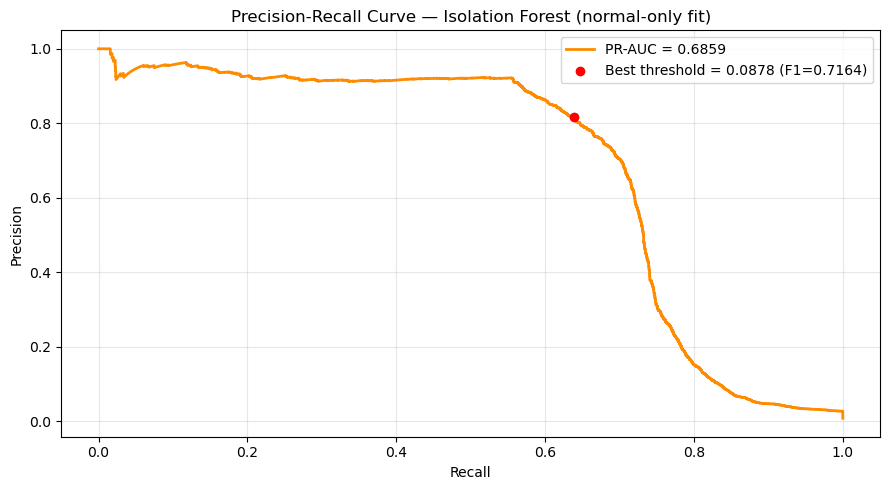


Optimal F1 threshold (on test scores): 0.087840
Best F1: 0.7164

Classification report at F1-optimal threshold:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    548246
       Fraud       0.82      0.64      0.72      4258

    accuracy                           1.00    552504
   macro avg       0.91      0.82      0.86    552504
weighted avg       1.00      1.00      1.00    552504



In [7]:
def anomaly_scores(model, X):
    return -model.decision_function(X)


y_score = anomaly_scores(iso_normal, X_test_scaled)

# sklearn predict: -1 = outlier (treat as fraud alert), 1 = inlier
y_pred_sklearn = (iso_normal.predict(X_test_scaled) == -1).astype(int)

pr_auc = average_precision_score(y_test, y_score)
roc_auc = roc_auc_score(y_test, y_score)

print("Classification report — sklearn default threshold (from training contamination):")
print(classification_report(y_test, y_pred_sklearn, target_names=["Legitimate", "Fraud"]))
print(f"PR-AUC (rank of anomaly score):  {pr_auc:.4f}")
print(f"ROC-AUC:                          {roc_auc:.4f}")
print(
    "\nPR-AUC is the headline metric under extreme imbalance; ROC can be optimistic when negatives dominate."
)

precision, recall, thresholds = precision_recall_curve(y_test, y_score)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
best_idx = int(np.argmax(f1_scores))
best_thresh = thresholds[best_idx]

plt.figure(figsize=(9, 5))
plt.plot(recall, precision, color="darkorange", lw=2, label=f"PR-AUC = {pr_auc:.4f}")
plt.scatter(
    recall[best_idx],
    precision[best_idx],
    color="red",
    zorder=5,
    label=f"Best threshold = {best_thresh:.4f} (F1={f1_scores[best_idx]:.4f})",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Isolation Forest (normal-only fit)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nOptimal F1 threshold (on test scores): {best_thresh:.6f}")
print(f"Best F1: {f1_scores[best_idx]:.4f}")

y_pred_opt = (y_score >= best_thresh).astype(int)
print("\nClassification report at F1-optimal threshold:")
print(classification_report(y_test, y_pred_opt, target_names=["Legitimate", "Fraud"]))

## 7. Confusion Matrices

Default (sklearn internal threshold) vs. F1-tuned threshold on test anomaly scores. **Note:** tuning the cutoff on the **test** set is optimistic for deployment; a stricter workflow would reserve a time slice of training data for calibration only.

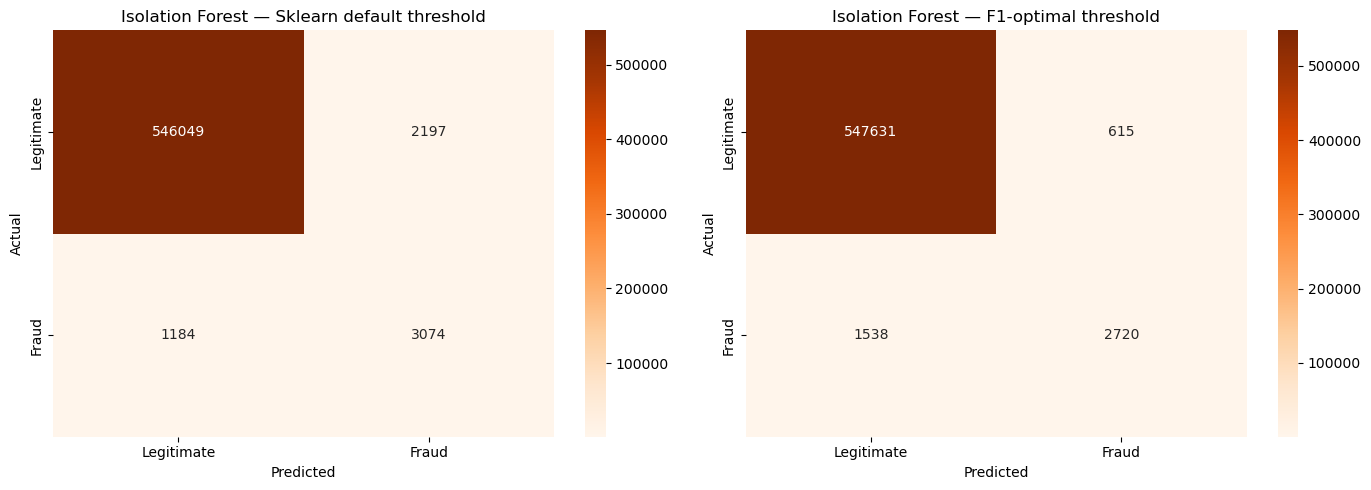

At F1-optimal threshold:
  True Positives  (caught fraud):   2,720
  False Negatives (missed fraud):   1,538
  False Positives (false alarms):   615
  True Negatives  (correct legit):  547,631


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, yp, title in zip(
    axes,
    [y_pred_sklearn, y_pred_opt],
    ["Sklearn default threshold", "F1-optimal threshold"],
):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Oranges",
        ax=ax,
        xticklabels=["Legitimate", "Fraud"],
        yticklabels=["Legitimate", "Fraud"],
    )
    ax.set_title(f"Isolation Forest — {title}")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt).ravel()
print("At F1-optimal threshold:")
print(f"  True Positives  (caught fraud):   {tp:,}")
print(f"  False Negatives (missed fraud):   {fn:,}")
print(f"  False Positives (false alarms):   {fp:,}")
print(f"  True Negatives  (correct legit):  {tn:,}")

## 8. Anomaly Score Distributions

Same idea as the Random Forest probability histograms: we want fraud cases to sit at **higher** `anomaly_score` than most legitimate transactions.

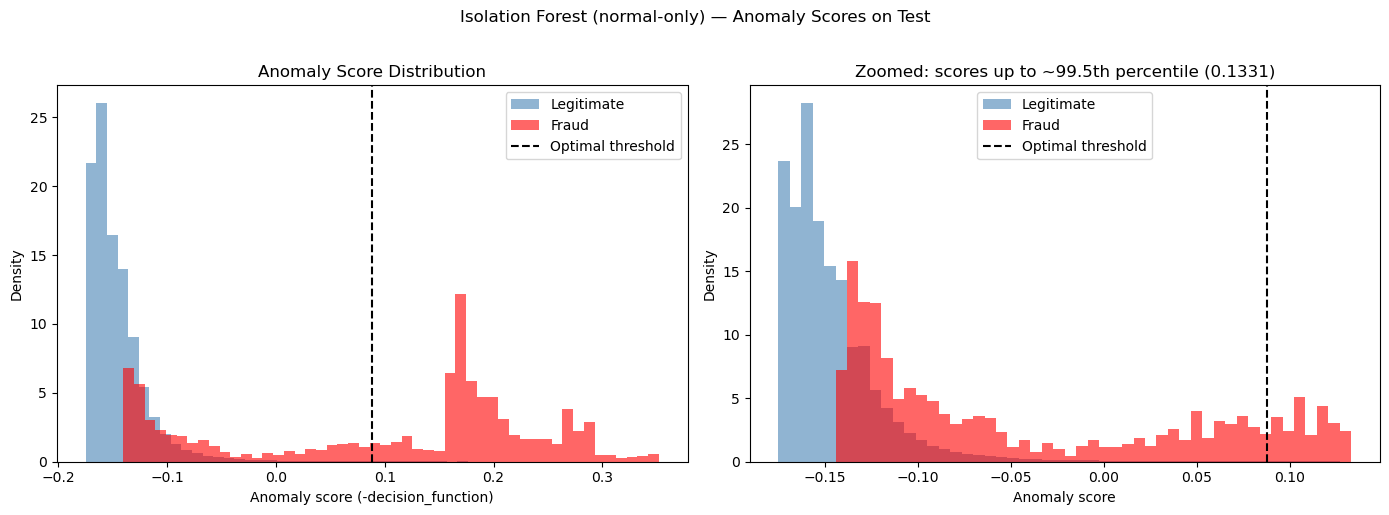

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    y_score[y_test == 0],
    bins=50,
    alpha=0.6,
    label="Legitimate",
    color="steelblue",
    density=True,
)
axes[0].hist(
    y_score[y_test == 1], bins=50, alpha=0.6, label="Fraud", color="red", density=True
)
axes[0].axvline(x=best_thresh, color="black", linestyle="--", label=f"Optimal threshold")
axes[0].set_xlabel("Anomaly score (-decision_function)")
axes[0].set_ylabel("Density")
axes[0].set_title("Anomaly Score Distribution")
axes[0].legend()

hi = np.percentile(y_score, 99.5)
axes[1].hist(
    y_score[y_test == 0],
    bins=50,
    alpha=0.6,
    label="Legitimate",
    color="steelblue",
    density=True,
    range=(y_score.min(), hi),
)
axes[1].hist(
    y_score[y_test == 1],
    bins=50,
    alpha=0.6,
    label="Fraud",
    color="red",
    density=True,
    range=(y_score.min(), hi),
)
axes[1].axvline(x=best_thresh, color="black", linestyle="--", label=f"Optimal threshold")
axes[1].set_xlabel("Anomaly score")
axes[1].set_ylabel("Density")
axes[1].set_title(f"Zoomed: scores up to ~99.5th percentile ({hi:.4f})")
axes[1].legend()

plt.suptitle("Isolation Forest (normal-only) — Anomaly Scores on Test", y=1.02)
plt.tight_layout()
plt.show()

## 9. Summary

| Aspect | Isolation Forest (this notebook) |
|---|---|
| Learning | Unsupervised; primary fit uses **no fraud labels** |
| Split | Time-based (same as Random Forest) |
| Features | Same engineered columns as PCA / RF |
| Scores | Higher anomaly score ⇒ more suspicious |
| Threshold | F1-optimal on PR curve (same idea as RF) |
| Key metric | PR-AUC |

**Compared to supervised RF / PCA+LR:**
- **Pro:** Framing matches "rare weird events" in a sea of legitimate data; no label leakage into the primary fit.
- **Con:** Legitimate heavy-tail transactions can score as outliers (precision cost); some fraud may not look globally anomalous (recall cost). Random Forest can exploit label structure and interactions more directly.